In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# !pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation,Dense,Flatten,BatchNormalization,Conv2D,MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)
%matplotlib inline

In [9]:
extract_path = "/content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined"
if os.path.exists(extract_path):
    print("Extracted files:", os.listdir(extract_path))
else:
    print("Extraction failed or path incorrect.")

Extracted files: ['Validation', 'Training', 'Testing']


In [10]:
for root, dirs, files in os.walk("/content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined"):
    print(root, dirs, files)

/content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined ['Validation', 'Training', 'Testing'] []
/content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined/Validation ['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined'] []
/content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined/Validation/Healthy Combined [] ['loh(83).JPG', 'loh(84).JPG', 'loh(85).JPG', 'loh(87).JPG', 'loh(91).JPG', 'loh(92).JPG', 'loh(88).JPG', 'loh(86).JPG', 'loh(90).JPG', 'loh(89).JPG', 'healthy_reconst_65.png', 'healthy_reconst_76.png', 'healthy_reconst_88 (1).png', 'healthy_reconst_88.png', 'healthy_reconst_90 (1).png', 'healthy_reconst_90.png', 'healthy_reconst_89 (1).png', 'healthy_reconst_89.png', 'healthy_reconst_87.png', 'healthy_reconst_97.png', 'healthy_reconst_98.png', 'healthy_reconst_96 (1).png', 'healthy_reconst_99.png', 'healthy_reconst_96.png']
/content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined/Validation/Septoria Combined [] ['los(11).JPG', 'los(33).JPG', 'l

In [11]:
training_path='/content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined/Training'
validation_path='/content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined/Validation'
testing_path='/content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined/Testing'

In [12]:
print("Training path:", training_path)
print("Validation path:", validation_path)
print("Testing path:", testing_path)

Training path: /content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined/Training
Validation path: /content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined/Validation
Testing path: /content/drive/MyDrive/wheat_leaf_combined/wheat_leaf_combined/Testing


In [18]:
train_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(training_path, target_size=(224,224), classes=['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined'], batch_size=32)

valid_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(validation_path, target_size=(224,224), classes=['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined'], batch_size=32)

test_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(testing_path, target_size=(224,224), classes=['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined'], batch_size=32)

Found 480 images belonging to 3 classes.
Found 64 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [19]:
# Preview a batch
x_batch, y_batch = next(train_batches)
print("Image shape:", x_batch.shape)
print("Pixel range (min to max):", x_batch.min(), "to", x_batch.max())


Image shape: (32, 224, 224, 3)
Pixel range (min to max): -113.68 to 151.061


In [20]:

# plots images with labels within jupyter notebook
def plots(ims, figsize=(12,6), rows=1, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims = np.array(ims).astype(np.uint8)
        if (ims.shape[-1] != 3):
            ims = ims.transpose((0,2,3,1))
    f = plt.figure(figsize=figsize)
    cols = len(ims)//rows if len(ims) % 2 == 0 else len(ims)//rows + 1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('Off')
        if titles is not None:
            sp.set_title(titles[i], fontsize=16)
        plt.imshow(ims[i], interpolation=None if interp else 'none')

In [21]:
imgs, labels = next(train_batches)

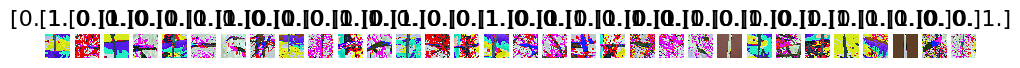

In [22]:
plots(imgs, titles=labels)

In [23]:
model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(224,224,3)),
        Flatten(),
        Dense(3, activation='softmax'),
    ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',     # Metric to monitor
    patience=10,             # Number of epochs to wait after no improvement
    verbose=1,              # Verbosity mode
    restore_best_weights=True # Restore the best weights after stopping
)

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1577088)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │     4,731,267 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,732,163 (18.05 MB)

 Trainable params: 4,732,163 (18.05 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.fit(train_batches, validation_data=valid_batches, epochs=50, callbacks=[early_stopping], verbose=2)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
15/15 - 240s - 16s/step - accuracy: 0.5667 - loss: 357.5635 - val_accuracy: 0.3906 - val_loss: 605.6447
Epoch 2/50
15/15 - 35s - 2s/step - accuracy: 0.7688 - loss: 112.7768 - val_accuracy: 0.5781 - val_loss: 194.9835
Epoch 3/50
15/15 - 36s - 2s/step - accuracy: 0.9083 - loss: 33.4185 - val_accuracy: 0.8125 - val_loss: 62.7144
Epoch 4/50
15/15 - 36s - 2s/step - accuracy: 0.9646 - loss: 10.0592 - val_accuracy: 0.8438 - val_loss: 32.9777
Epoch 5/50
15/15 - 41s - 3s/step - accuracy: 0.9729 - loss: 6.6106 - val_accuracy: 0.8125 - val_loss: 41.3743
Epoch 6/50
15/15 - 37s - 2s/step - accuracy: 0.9646 - loss: 8.9640 - val_accuracy: 0.7812 - val_loss: 68.8215
Epoch 7/50
15/15 - 38s - 3s/step - accuracy: 0.9479 - loss: 17.3396 - val_accuracy: 0.7969 - val_loss: 77.4273
Epoch 8/50
15/15 - 40s - 3s/step - accuracy: 0.9729 - loss: 3.4283 - val_accuracy: 0.8281 - val_loss: 75.5459
Epoch 9/50
15/15 - 36s - 2s/step - accuracy: 0.9812 - loss: 1.8189 - val_accuracy: 0.6562 - val_loss: 84.8952

In [28]:
print(f"Stopped at epoch: {early_stopping.stopped_epoch}")


Stopped at epoch: 13


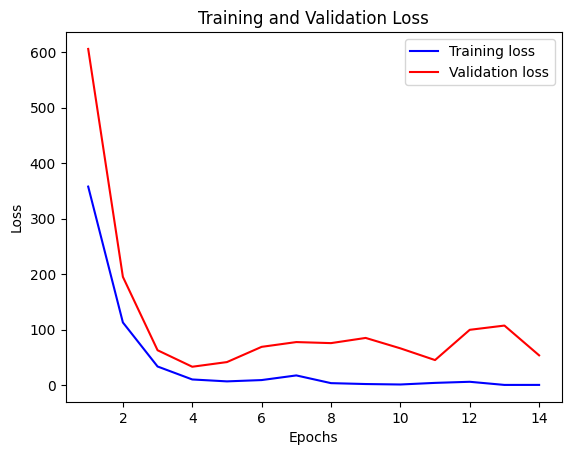

In [29]:
# prompt: plot training, testing and validation loss

import matplotlib.pyplot as plt

# Assuming 'history' object contains the training history from model.fit
# history = model.fit(...)

# Access the loss values
training_loss = model.history.history['loss']
validation_loss = model.history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(training_loss) + 1)  # Assuming epochs are available

plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


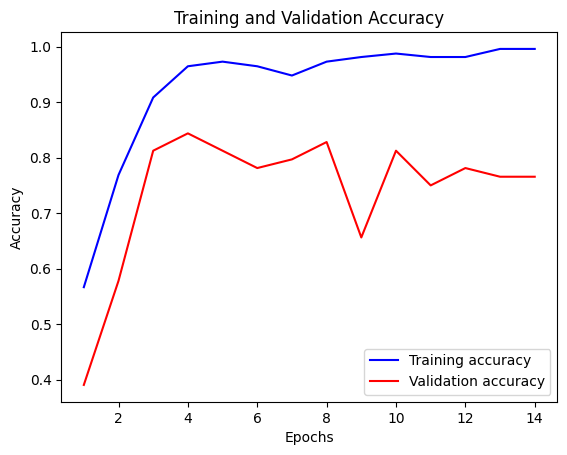

In [30]:
# Plot training and validation accuracy
training_accuracy = model.history.history['accuracy']
validation_accuracy = model.history.history['val_accuracy']

plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [31]:
# Evaluate on training set
train_loss, train_accuracy = model.evaluate(train_batches, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(valid_batches, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_batches, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Training Loss: 4.7352
Training Accuracy: 98.33%
Validation Loss: 32.9777
Validation Accuracy: 84.38%
Test Loss: 51.4052
Test Accuracy: 81.67%


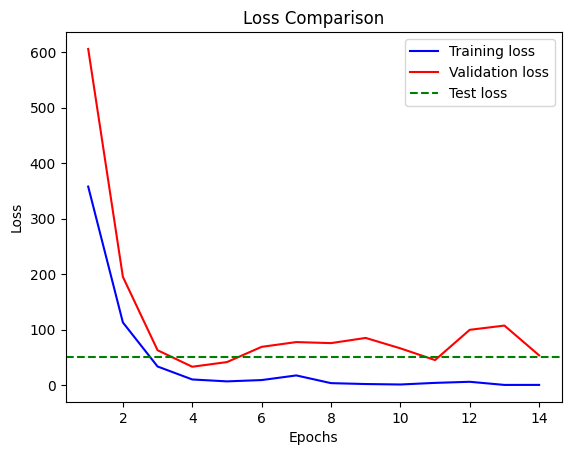

In [32]:
# Plot test loss and accuracy for comparison
plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.axhline(y=test_loss, color='g', linestyle='--', label='Test loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

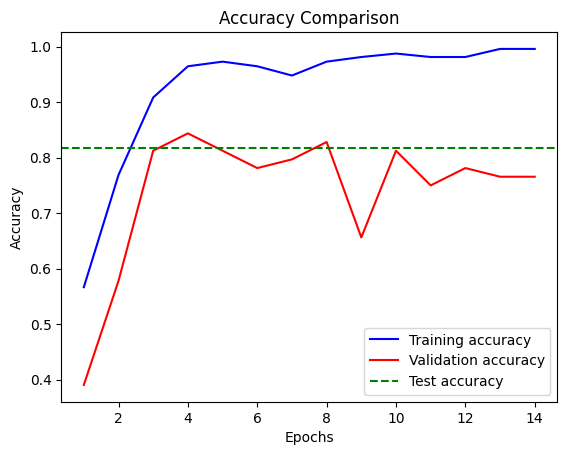

In [33]:
plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [34]:
test_imgs, test_labels = next(test_batches)

# Get the model predictions
predictions = model.predict(test_imgs)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=-1)

# Print actual vs predicted labels (indices)
print(f"Actual labels: {test_labels}")
print(f"Predicted labels (indices): {predicted_classes}")

# Optionally, print the class names:
class_names = ['Healthy', 'Septoria', 'Stripe_rust']
predicted_class_names = [class_names[i] for i in predicted_classes]
print(f"Predicted class names: {predicted_class_names}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Actual labels: [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]]
Predicted labels (indices): [0 0 0 2 2 1 0 1 1 0 2 2 1 1 0 0 0 0 1 1 1 2 1 1 2 1 1 1 0 2 1 2]
Predicted class names: ['Healthy', 'Healthy', 'Healthy', 'Stripe_rust', 'Stripe_rust', 'Septoria', 'Healthy', 'Septoria', 'Septoria', 'Healthy', 'Stripe_rust', 'Stripe_rust', 'Septoria', 'Septoria', 'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Septoria', 'Septoria', 'Septoria', 'Stripe_rust', 'Septoria', 'Septoria', 'Stripe_rust', 'Septoria', 'Septoria', 'Septoria', 'Healthy', 'Stripe_rust', 'Septoria', 'Stripe_rust']


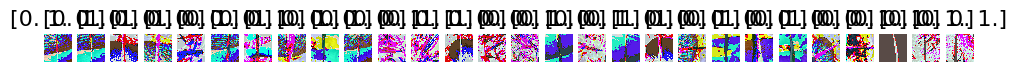

In [35]:
test_imgs, test_labels = next(test_batches)
plots(test_imgs, titles=test_labels)

In [36]:
test_labels = test_labels[:,0]
test_labels

array([0., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0.], dtype=float32)

In [46]:
predictions = model.predict(test_batches, steps=1, verbose=0)

In [47]:
predictions.round(2)

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], dtype=float32)

In [48]:
cm = confusion_matrix(test_labels, [np.argmax(i) for i in predictions])

In [49]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [50]:
print("Training classes:", os.listdir(training_path))
print("Validation classes:", os.listdir(validation_path))
print("Testing classes:", os.listdir(testing_path))


Training classes: ['Healthy Combined', 'Stripe Rust Combined', 'Septoria Combined']
Validation classes: ['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined']
Testing classes: ['Healthy Combined', 'Septoria Combined', 'Stripe Rust Combined']


Confusion matrix, without normalization
[[ 8  4  0]
 [ 0 12  0]
 [ 3  0  5]]


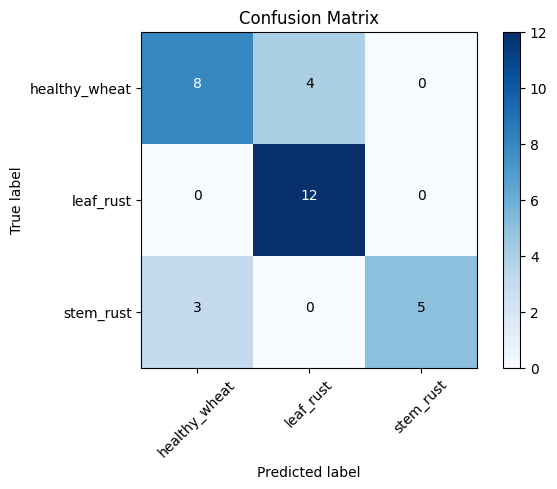

In [51]:
cm_plot_labels = ['healthy_wheat','leaf_rust','stem_rust']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix')

In [52]:
vgg16_model = keras.applications.vgg16.VGG16()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step


In [53]:
vgg16_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
type(vgg16_model)

keras.src.models.functional.Functional

In [55]:

model = Sequential()
for layer in vgg16_model.layers:
    model.add(layer)

In [56]:

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.layers.pop()

<Dense name=predictions, built=True>

In [58]:
for layer in model.layers:
    layer.trainable = False

In [59]:
model.add(Dense(3, activation='softmax'))

In [60]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,003 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,360,547 (527.80 MB)

 Trainable params: 3,003 (11.73 KB)

 Non-trainable params: 138,357,544 (527.79 MB)

In [61]:
model.compile(Adam(learning_rate=.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [62]:
history = model.fit(train_batches, validation_data=valid_batches, epochs=50, callbacks=[early_stopping], verbose=2)


Epoch 1/50
15/15 - 58s - 4s/step - accuracy: 0.3167 - loss: 1.0983 - val_accuracy: 0.2500 - val_loss: 1.0996
Epoch 2/50
15/15 - 38s - 3s/step - accuracy: 0.3583 - loss: 1.0978 - val_accuracy: 0.2500 - val_loss: 1.0994
Epoch 3/50
15/15 - 39s - 3s/step - accuracy: 0.3938 - loss: 1.0974 - val_accuracy: 0.2812 - val_loss: 1.0992
Epoch 4/50
15/15 - 38s - 3s/step - accuracy: 0.4250 - loss: 1.0970 - val_accuracy: 0.3125 - val_loss: 1.0990
Epoch 5/50
15/15 - 40s - 3s/step - accuracy: 0.4646 - loss: 1.0966 - val_accuracy: 0.2969 - val_loss: 1.0987
Epoch 6/50
15/15 - 38s - 3s/step - accuracy: 0.4792 - loss: 1.0962 - val_accuracy: 0.3281 - val_loss: 1.0985
Epoch 7/50
15/15 - 39s - 3s/step - accuracy: 0.4958 - loss: 1.0958 - val_accuracy: 0.3438 - val_loss: 1.0983
Epoch 8/50
15/15 - 37s - 2s/step - accuracy: 0.5208 - loss: 1.0953 - val_accuracy: 0.3594 - val_loss: 1.0981
Epoch 9/50
15/15 - 37s - 2s/step - accuracy: 0.5437 - loss: 1.0949 - val_accuracy: 0.3594 - val_loss: 1.0979
Epoch 10/50
15/15 -

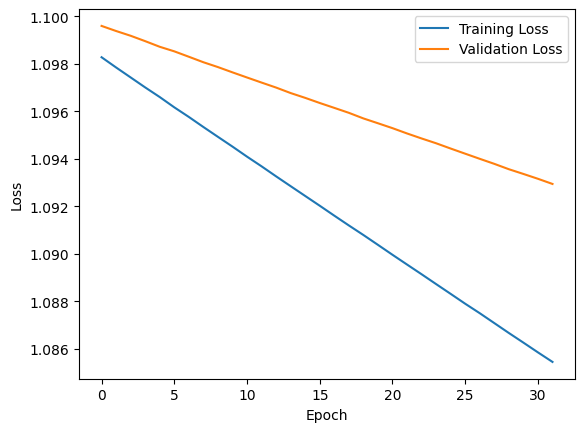

In [63]:
# prompt: Plot training and validation loss

# Plot training and validation loss
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


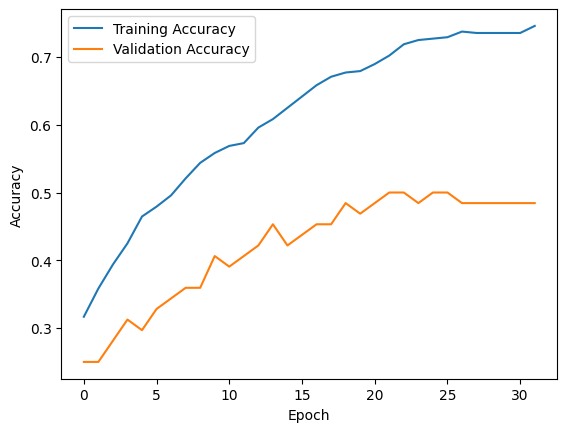

In [64]:
# prompt: plot training an validation accuracy

# Plot training and validation accuracy
plt.plot(model.history.history['accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [65]:
# Evaluate on training set
train_loss, train_accuracy = model.evaluate(train_batches, verbose=0)
print(f"Training Loss on VGG16: {train_loss:.4f}")
print(f"Training Accuracy on VGG16: {train_accuracy*100:.2f}%")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(valid_batches, verbose=0)
print(f"Validation Loss on VGG16: {val_loss:.4f}")
print(f"Validation Accuracy on VGG16: {val_accuracy*100:.2f}%")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_batches, verbose=0)
print(f"Test Loss on VGG16: {test_loss:.4f}")
print(f"Test Accuracy on VGG16: {test_accuracy*100:.2f}%")


Training Loss on VGG16: 1.0893
Training Accuracy on VGG16: 71.67%
Validation Loss on VGG16: 1.0951
Validation Accuracy on VGG16: 50.00%
Test Loss on VGG16: 1.0936
Test Accuracy on VGG16: 55.00%


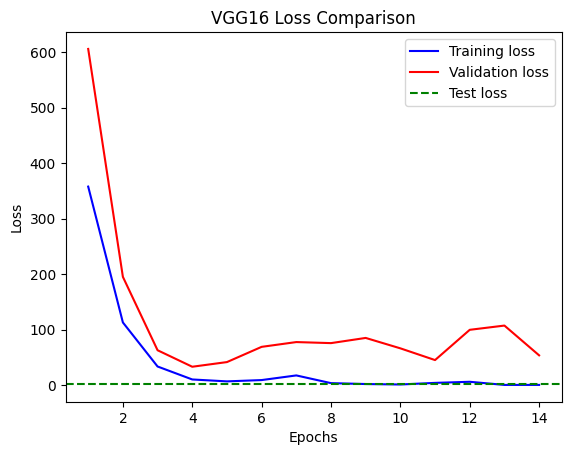

In [71]:
# Plot test loss and accuracy for comparison
plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.axhline(y=test_loss, color='g', linestyle='--', label='Test loss')
plt.title('VGG16 Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

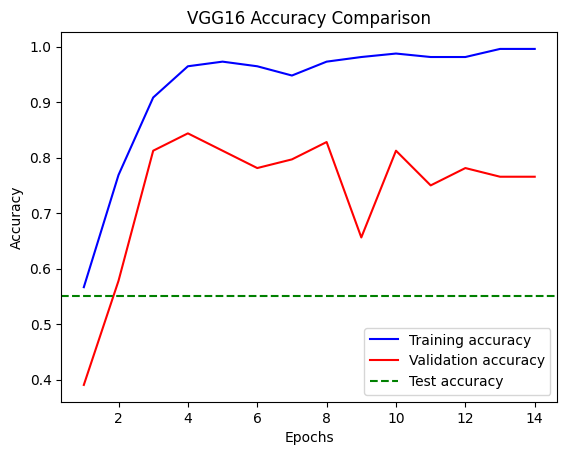

In [72]:
plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test accuracy')
plt.title('VGG16 Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

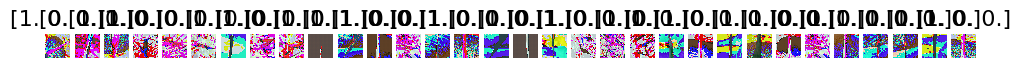

In [73]:

test_imgs, test_labels = next(test_batches)
plots(test_imgs, titles=test_labels)

In [74]:
test_labels = test_labels[:,0]
test_labels

array([1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
       0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1.],
      dtype=float32)

In [75]:

predictions = model.predict(test_batches, steps=1, verbose=0)

In [76]:
cm = confusion_matrix(test_labels, [np.argmax(i) for i in predictions])

Confusion matrix, without normalization
[[6 9 5]
 [4 3 5]
 [0 0 0]]


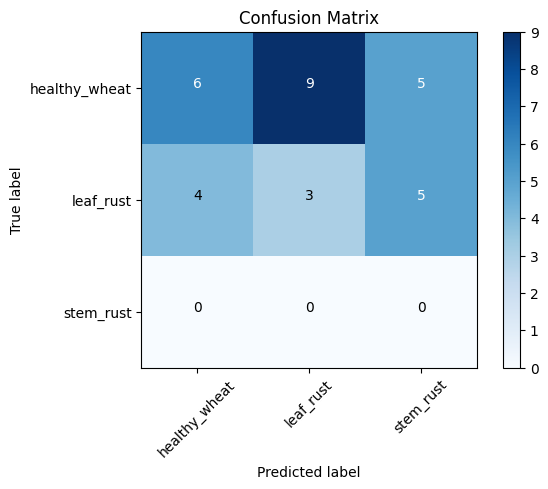

In [77]:

cm_plot_labels = ['healthy_wheat','leaf_rust','stem_rust']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix')

In [78]:
from sklearn.metrics import classification_report
cr=classification_report(test_labels, [np.argmax(i) for i in predictions],target_names=cm_plot_labels,)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [79]:
print(cr)

               precision    recall  f1-score   support

healthy_wheat       0.60      0.30      0.40        20
    leaf_rust       0.25      0.25      0.25        12
    stem_rust       0.00      0.00      0.00         0

     accuracy                           0.28        32
    macro avg       0.28      0.18      0.22        32
 weighted avg       0.47      0.28      0.34        32



In [80]:
model.evaluate(test_batches)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5646 - loss: 1.0935


[1.0935720205307007, 0.550000011920929]